In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, BatchNormalization, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report

## **Mount Google Drive**



In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Dataset Location

dataLocation = "/content/drive/MyDrive/Brain_Tumor_Model_Creation"

In [ ]:
print("Train:", os.listdir(dataLocation + "/train"))
print("Validation:", os.listdir(dataLocation + "/validation"))
print("Test:", os.listdir(dataLocation + "/test"))

Train: ['top', 'not_top']
Validation: ['top', 'not_top']
Test: ['top', 'not_top']


##**Image Resize**

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

##**Data Generators**

In [ ]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    zoom_range = 0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip = True,
    brightness_range=[0.8, 1.2]
)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
val_datagen   = ImageDataGenerator(rescale=1./255)

##**Load Dataset**

Training Data

In [ ]:
train_data = train_datagen.flow_from_directory(
    directory = dataLocation + "/train",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE,
    class_mode = "binary"
)

Found 1600 images belonging to 2 classes.


Validation Data

In [ ]:
val_data = val_datagen.flow_from_directory(
    directory=dataLocation + "/validation",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

Found 200 images belonging to 2 classes.


Test Data

In [ ]:
test_data = test_datagen.flow_from_directory(
    directory=dataLocation + "/test",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE,
    class_mode = "binary"
)

Found 200 images belonging to 2 classes.


Verify Labeling

In [ ]:
print(train_data.class_indices)
print(val_data.class_indices)

{'not_top': 0, 'top': 1}
{'not_top': 0, 'top': 1}


In [ ]:
"""batch_index = np.random.randint(0, train_data.samples // train_data.batch_size)
train_data.reset()

for _ in range(batch_index):
    next(train_data)

images, labels = next(train_data)

idx = np.random.randint(0, len(images))
plt.imshow(images[idx])
plt.axis('off')
plt.show()"""


"batch_index = np.random.randint(0, train_data.samples // train_data.batch_size)\ntrain_data.reset()\n\nfor _ in range(batch_index):\n    next(train_data)\n\nimages, labels = next(train_data)\n\nidx = np.random.randint(0, len(images))\nplt.imshow(images[idx])\nplt.axis('off')\nplt.show()"

##**Model**

In [ ]:
model = Sequential()

layer 1

In [ ]:
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


layer 2

In [ ]:
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))


layer 3

In [ ]:
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))


Flatten_Decision layer

In [ ]:
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.6))
model.add(Dense(1, activation='sigmoid'))


##**Model Complie**


In [ ]:
optimizer = Adam(learning_rate=0.0001)
model.compile(
    loss = 'binary_crossentropy',
    optimizer = optimizer,
    metrics = ['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'stage1_topview_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)


In [ ]:
class_weights = {0: 1.0, 1: 1.0}

In [ ]:
EPOCHS = 20

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint],
    class_weight = class_weights
)


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9221 - loss: 0.2020

50/50 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.9220 - loss: 0.2024 - val_accuracy: 0.5000 - val_loss: 1.7141
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9327 - loss: 0.1943 - val_accuracy: 0.5000 - val_loss: 2.2668
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9656 - loss: 0.0981 - val_accuracy: 0.5000 - val_loss: 1.9280
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9705 - loss: 0.0974

50/50 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9704 - loss: 0.0976 - val_accuracy: 0.5250 - val_loss: 1.1501
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9741 - loss: 0.0665

50/50 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9740 - loss: 0.0665 - val_accuracy: 0.7050 - val_loss: 0.6128
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9705 - loss: 0.0796

50/50 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9704 - loss: 0.0800 - val_accuracy: 0.7200 - val_loss: 0.5123
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9652 - loss: 0.0795

50/50 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9652 - loss: 0.0795 - val_accuracy: 0.9400 - val_loss: 0.1838
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9729 - loss: 0.0614

50/50 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9730 - loss: 0.0613 - val_accuracy: 0.9750 - val_loss: 0.0631
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.9768 - loss: 0.0644 - val_accuracy: 0.9750 - val_loss: 0.0457
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9795 - loss: 0.0494

50/50 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9794 - loss: 0.0496 - val_accuracy: 0.9800 - val_loss: 0.0296
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9833 - loss: 0.0497

50/50 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.9832 - loss: 0.0498 - val_accuracy: 0.9900 - val_loss: 0.0099
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.9740 - loss: 0.0737 - val_accuracy: 0.9850 - val_loss: 0.0237
Epoch 13/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.9824 - loss: 0.0483 - val_accuracy: 0.9800 - val_loss: 0.1054
Epoch 14/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9829 - loss: 0.0416 - val_accuracy: 0.9800 - val_loss: 0.0770
Epoch 15/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9888 - loss: 0.0452 - val_accuracy: 0.9750 - val_loss: 0.0883
Epoch 16/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9910 - loss: 0.0278

50/50 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9909 - loss: 0.0280 - val_accuracy: 0.9950 - val_loss: 0.0127


In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Stage-1 Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 354ms/step - accuracy: 1.0000 - loss: 0.0079
Stage-1 Test Accuracy: 1.0


##**Model Testing**

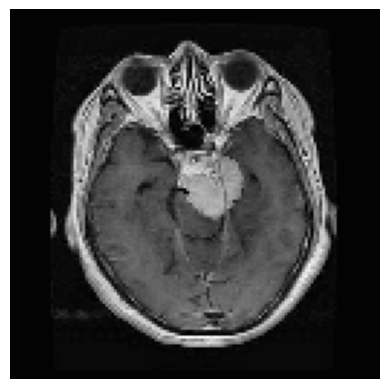

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Prediction: Top-View Detected.
Confidence: 100.00%


In [ ]:
#Image path
idx = random.randint(0, len(test_data.filepaths) - 1)
img_path = test_data.filepaths[idx]

#Load image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0   # rescale
img_array = np.expand_dims(img_array, axis=0)

#Show image
plt.imshow(img)
plt.axis('off')
plt.show()

#Predict
prediction = model.predict(img_array)[0][0]

#Predicted Output
if prediction > 0.5:
  pred = "Top-View Detected."
else:
  pred = "Not a Top-View of Head."

#Confidence
if prediction > 0.5:
  confidence = prediction
else:
  confidence = 1 - prediction

print(f"Prediction: {pred}")
print(f"Confidence: {confidence:.2%}")


In [ ]:
y_true = test_data.classes
y_pred_probs = model.predict(test_data)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()

print(classification_report(y_true, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 599ms/step
              precision    recall  f1-score   support

           0       0.53      0.53      0.53       100
           1       0.53      0.53      0.53       100

    accuracy                           0.53       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.53      0.53      0.53       200



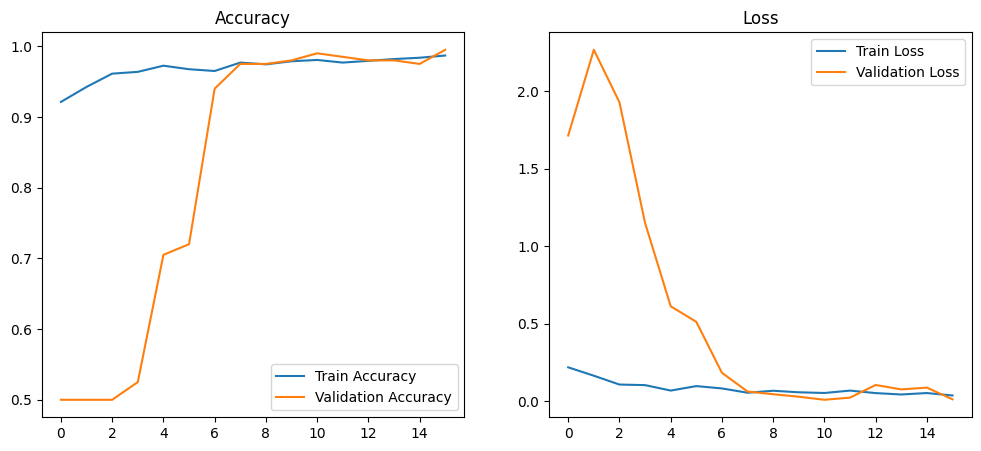

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()


I dont know why i am doing this

In [ ]:
y_pred = model.predict(val_data)
print("Pred probs:", y_pred[:10].ravel())
print("Pred classes:", (y_pred > 0.5).astype(int).ravel()[:10])
print("True classes:", val_data.classes[:10])

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 453ms/step
Pred probs: [9.9977922e-01 8.6102973e-06 9.8519695e-01 9.9765474e-01 1.6546834e-07
 5.8233980e-03 9.9999183e-01 4.0432137e-06 9.9960887e-01 3.0979857e-06]
Pred classes: [1 0 1 1 0 0 1 0 1 0]
True classes: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
y_pred = model.predict(val_data)
print("Pred probs:", y_pred[:10].ravel())
print("Pred classes:", (y_pred > 0.5).astype(int).ravel()[:10])
print("True classes:", val_data.classes[:10])

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 369ms/step
Pred probs: [5.58882239e-05 4.93713915e-01 1.88036924e-04 1.69625364e-05
 9.99998808e-01 9.99992549e-01 1.06839594e-04 9.99119163e-01
 9.99955177e-01 9.99979854e-01]
Pred classes: [0 0 0 0 1 1 0 1 1 1]
True classes: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
import numpy as np
print("Train label counts:", np.bincount(train_data.classes))
print("Val label counts:", np.bincount(val_data.classes))

Train label counts: [800 800]
Val label counts: [100 100]


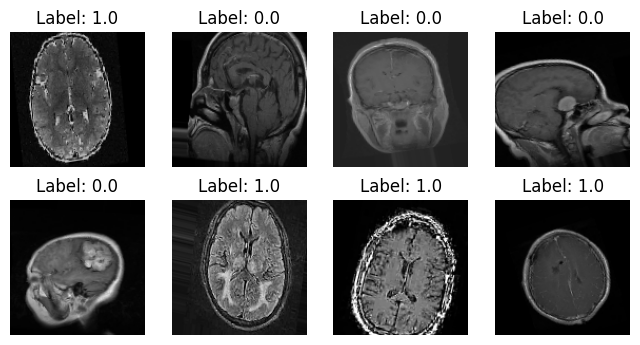

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.title(f"Label: {labels[i]}")
    plt.axis("off")
plt.show()

In [ ]:
print("Min pixel:", images.min())
print("Max pixel:", images.max())

Min pixel: 0.0
Max pixel: 1.0


In [ ]:
base.trainable = True

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # small LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

NameError: name 'base' is not defined